In [1]:
import os,re,subprocess,math,requests
from bs4 import BeautifulSoup
from urllib.parse import urljoin

In [2]:
import gzip,glob
from lxml import etree
from tqdm import tqdm

In [3]:
BASE_URL = "https://ftp.ncbi.nlm.nih.gov/pubmed/baseline/"
TARGET_UNCOMPRESSED_GB = 4.0
DEST = "/content/pubmed_xml_subset"
os.makedirs(DEST, exist_ok=True)

In [4]:
html=requests.get(BASE_URL,timeout=60).text
soup=BeautifulSoup(html,'html.parser')

hrefs=[a.get('href') for a in soup.find_all('a',href=True)]
gz_files=sorted([h for h in hrefs if h.endswith('.gz')])

print(f'found {len(gz_files)} .gz files on the baseline index')

found 1334 .gz files on the baseline index


In [5]:

# 2) Download sequentially until uncompressed total ≈ target
def gz_uncompressed_bytes(local_path):
    # Use gzip -l to read uncompressed size from footer (fast; no full decompress)
    out = subprocess.check_output(["gzip", "-l", local_path]).decode()
    # The second line has: compressed  uncompressed  ratio  uncompressed_name
    lines = out.strip().splitlines()
    if len(lines) >= 2:
        parts = re.split(r"\s+", lines[1].strip())
        # parts[1] = uncompressed bytes
        return int(parts[1])
    return 0

total_uncompressed = 0
downloaded = []

for fname in gz_files:
    url = urljoin(BASE_URL, fname)
    local = os.path.join(DEST, fname)
    if not os.path.exists(local):
        print(f"→ downloading {fname} ...")
        # quiet, continue on partial, retry a bit
        ret = subprocess.call(["wget", "-q", "-c", "-O", local, url])
        if ret != 0:
            print(f"  ! failed: {fname}; skipping")
            if os.path.exists(local): os.remove(local)
            continue
    # read uncompressed size
    try:
        ub = gz_uncompressed_bytes(local)
        total_uncompressed += ub
        downloaded.append((fname, ub))
        print(f"  added {fname}: {ub/1e9:.3f} GB uncompressed  |  total ≈ {total_uncompressed/1e9:.3f} GB")
    except Exception as e:
        print(f"  ! could not read size for {fname}: {e}")

    if total_uncompressed >= TARGET_UNCOMPRESSED_GB * 1e9:
        print("\nTarget reached. Stopping downloads.")
        break

print(f"\nDone. Saved {len(downloaded)} files to: {DEST}")
print(f"Approx. uncompressed total: {total_uncompressed/1e9:.3f} GB")

→ downloading pubmed26n0001.xml.gz ...
  added pubmed26n0001.xml.gz: 0.195 GB uncompressed  |  total ≈ 0.195 GB
→ downloading pubmed26n0002.xml.gz ...
  added pubmed26n0002.xml.gz: 0.183 GB uncompressed  |  total ≈ 0.378 GB
→ downloading pubmed26n0003.xml.gz ...
  added pubmed26n0003.xml.gz: 0.175 GB uncompressed  |  total ≈ 0.553 GB
→ downloading pubmed26n0004.xml.gz ...
  added pubmed26n0004.xml.gz: 0.183 GB uncompressed  |  total ≈ 0.736 GB
→ downloading pubmed26n0005.xml.gz ...
  added pubmed26n0005.xml.gz: 0.175 GB uncompressed  |  total ≈ 0.911 GB
→ downloading pubmed26n0006.xml.gz ...
  added pubmed26n0006.xml.gz: 0.201 GB uncompressed  |  total ≈ 1.113 GB
→ downloading pubmed26n0007.xml.gz ...
  added pubmed26n0007.xml.gz: 0.204 GB uncompressed  |  total ≈ 1.316 GB
→ downloading pubmed26n0008.xml.gz ...
  added pubmed26n0008.xml.gz: 0.199 GB uncompressed  |  total ≈ 1.515 GB
→ downloading pubmed26n0009.xml.gz ...
  added pubmed26n0009.xml.gz: 0.127 GB uncompressed  |  total ≈ 1

In [6]:
SRC_DIR = "/content/pubmed_xml_subset"         # where your .xml.gz files are
OUT_DIR = "/content/pubmed_txt"                # output folder
os.makedirs(OUT_DIR, exist_ok=True)

train_path=f"{OUT_DIR}/train.txt"
valid_path=f'{OUT_DIR}/valid.txt'
test_path=f'{OUT_DIR}/test.txt'

def yield_title_abstract(fp):
    # iterparse to avoid loading whole XML into RAM
    ctx = etree.iterparse(gzip.open(fp), events=("end",), tag="PubmedArticle")
    for _, elem in ctx:
        # Title
        t = elem.find(".//ArticleTitle")
        title = (t.text or "").strip() if t is not None else ""
        # Abstract may have multiple parts <AbstractText>
        abs_nodes = elem.findall(".//AbstractText")
        abs_parts = []
        for a in abs_nodes:
            txt = (a.text or "").strip()
            if txt:
                abs_parts.append(txt)
        abstract = " ".join(abs_parts).strip()

        if title and abstract:
            text = f"{title}. {abstract}"
            # clean newlines/tabs
            text = " ".join(text.split())
            yield text

        # free memory
        elem.clear()
        while elem.getprevious() is not None:
            del elem.getparent()[0]
    del ctx

# ----- collect and write -----
gz_files = sorted(glob.glob(os.path.join(SRC_DIR, "*.xml.gz")))
print(f"Found {len(gz_files)} gz files")

# We'll stream all docs, then do a simple split by count.
all_out = f"{OUT_DIR}/_all.txt"
with open(all_out, "w", encoding="utf-8") as out:
    for fp in tqdm(gz_files, desc="Parsing"):
        for line in yield_title_abstract(fp):
            out.write(line + "\n")

# Quick stats
num_lines = sum(1 for _ in open(all_out, "r", encoding="utf-8"))
print("Total docs with title+abstract:", num_lines)

# Split 98% / 1% / 1% (adjust if you like)
train_n = int(num_lines * 0.98)
valid_n = int(num_lines * 0.01)
test_n  = num_lines - train_n - valid_n

with open(all_out, "r", encoding="utf-8") as fin, \
     open(train_path, "w", encoding="utf-8") as ftr, \
     open(valid_path, "w", encoding="utf-8") as fva, \
     open(test_path,  "w", encoding="utf-8") as fte:
    for i, line in enumerate(fin):
        if i < train_n: ftr.write(line)
        elif i < train_n + valid_n: fva.write(line)
        else: fte.write(line)

print("Wrote:")
print(" ", train_path)
print(" ", valid_path)
print(" ", test_path)


Found 24 gz files


Parsing: 100%|██████████| 24/24 [02:02<00:00,  5.09s/it]


Total docs with title+abstract: 311800
Wrote:
  /content/pubmed_txt/train.txt
  /content/pubmed_txt/valid.txt
  /content/pubmed_txt/test.txt


In [7]:
# Colab cell: Install tools
!pip -q install sacremoses==0.0.53
!sudo apt-get -y install g++ >/dev/null

# fastBPE (build once)
!git clone -q https://github.com/glample/fastBPE.git /content/fastBPE
%cd /content/fastBPE
!g++ -std=c++11 -O3 -pthread fastBPE/main.cc -IfastBPE -o fast
%cd /content

# fairseq (0.12.0 recommended for GPT2-medium arch flag)
!git clone -q https://github.com/pytorch/fairseq.git /content/fairseq
%cd /content/fairseq
!git checkout v0.12.0 -q
!pip -q install .
%cd /content

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 880.6/880.6 kB 41.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
/content/fastBPE
/content
/content/fairseq
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
Requested omegaconf<2.1 from https://files.pythonhosted.org/packages/d0/eb/9d63ce09dd8aa85767c65668d5414958ea29648a0eec80a4a7d311ec2684/omegaconf-2.0.6-py3-none-any.whl (from fairseq==0.12.0) has invalid metadata: .* suffix can only be used with `==` or `!=` operators
    PyYAML (>=5.1.*)
            ~~~~~~^
Please use pip<24.1 if you need to use this version.
Requested omegaconf<2.1 from https://files.pythonhosted.org/packages/e5/f6/043b6d255dd6fbf2025110cea35b87f4c5100a181681d8eab496269f0d5b/omegaconf-2.0.5-py3-none-any.whl (from fairseq==0.12.0) has invalid metadata: .* suffix can only be used with `==` or `!=` operators
    PyYAML (>=5.1.*)
    

In [8]:
!wget -q -O /content/bpecodes https://raw.githubusercontent.com/microsoft/BioGPT/main/data/BioGPT/bpecodes
!wget -q -O /content/dict.txt  https://raw.githubusercontent.com/microsoft/BioGPT/main/data/BioGPT/dict.txt
!wc -l /content/dict.txt && head -n 5 /content/dict.txt

42380 /content/dict.txt
. 142442146
of 136351517
the 133562497
, 127378192
and 105334276


In [9]:
import os
from sacremoses import MosesTokenizer
from tqdm.auto import tqdm

TXT_DIR = "/content/pubmed_txt"
BPE_DIR = "/content/pubmed_bpe"
os.makedirs(BPE_DIR, exist_ok=True)

mt = MosesTokenizer(lang="en")

def tokenize_file(in_path, out_path, show_progress=True):
    # Count lines once for a nice total
    with open(in_path, "r", encoding="utf-8") as f:
        total = sum(1 for _ in f)

    with open(in_path, "r", encoding="utf-8") as fin, \
         open(out_path, "w", encoding="utf-8") as fout:
        iterator = fin
        if show_progress:
            iterator = tqdm(fin, total=total, desc=f"Tokenizing {os.path.basename(in_path)}")
        for line in iterator:
            line = line.strip()
            if not line:
                continue
            fout.write(mt.tokenize(line, return_str=True) + "\n")

for split in ["train", "valid", "test"]:
    tok = f"{BPE_DIR}/{split}.tok"
    bpe = f"{BPE_DIR}/{split}.bpe"
    tokenize_file(f"{TXT_DIR}/{split}.txt", tok)

Tokenizing train.txt:   0%|          | 0/305564 [00:00<?, ?it/s]

Tokenizing valid.txt:   0%|          | 0/3118 [00:00<?, ?it/s]

Tokenizing test.txt:   0%|          | 0/3118 [00:00<?, ?it/s]

In [10]:
import os, math, subprocess, numpy as np, shutil
from tqdm.auto import tqdm

BPE_CODES = "/content/bpecodes"     # BioGPT bpecodes
DICT_TXT  = "/content/dict.txt"     # BioGPT dict
BPE_DIR   = "/content/pubmed_bpe"   # where your .tok files are
BIN_DIR   = "/content/pubmed_memmap"
TMP_DIR   = "/content/_bpe_tmp"
os.makedirs(BIN_DIR, exist_ok=True)
os.makedirs(TMP_DIR, exist_ok=True)

# --- load vocab ---
token2id = {}
with open(DICT_TXT, encoding="utf-8") as f:
    for i, line in enumerate(f):
        tok = line.split()[0]
        token2id[tok] = i
# choose a fallback id ONLY IF we see OOVs later
fallback_id = token2id.get("</s>", next(iter(token2id.values())))  # prefer EOS, else first token

# --- ensure fastBPE binary exists ---
if not os.path.exists("/content/fastBPE/fast"):
    !git clone -q https://github.com/glample/fastBPE.git /content/fastBPE
    %cd /content/fastBPE
    !g++ -std=c++11 -O3 -pthread fastBPE/main.cc -IfastBPE -o fast
    %cd /content

def line_count(path):
    c = 0
    with open(path, encoding="utf-8") as f:
        for _ in f:
            c += 1
    return c

def apply_bpe_with_progress(tok_file, bpe_file, shards=50):
    total_lines = line_count(tok_file)
    if total_lines == 0:
        open(bpe_file, "w").close()
        return

    shards = max(1, min(shards, total_lines))
    lines_per = math.ceil(total_lines / shards)

    split_dir = os.path.join(TMP_DIR, "split")
    out_dir   = os.path.join(TMP_DIR, "bpe_parts")
    os.makedirs(split_dir, exist_ok=True)
    os.makedirs(out_dir, exist_ok=True)

    # 1) split with progress
    with open(tok_file, encoding="utf-8") as fin:
        shard_idx = 0
        line_idx  = 0
        fout = None
        pbar = tqdm(total=total_lines, desc=f"Splitting {os.path.basename(tok_file)}")
        for line in fin:
            if line_idx % lines_per == 0:
                if fout: fout.close()
                shard_idx += 1
                fout = open(os.path.join(split_dir, f"part_{shard_idx:05d}.tok"), "w", encoding="utf-8")
            fout.write(line)
            line_idx += 1
            pbar.update(1)
        if fout: fout.close()
        pbar.close()

    # 2) BPE on each shard with progress
    parts = sorted([p for p in os.listdir(split_dir) if p.endswith(".tok")])
    for p in tqdm(parts, desc="Applying BPE to shards"):
        src = os.path.join(split_dir, p)
        dst = os.path.join(out_dir, p.replace(".tok", ".bpe"))
        subprocess.check_call(["/content/fastBPE/fast", "applybpe", dst, src, BPE_CODES])

    # 3) concat with progress
    with open(bpe_file, "w", encoding="utf-8") as fout:
        for p in tqdm(parts, desc="Concatenating BPE shards"):
            src = os.path.join(out_dir, p.replace(".tok", ".bpe"))
            with open(src, encoding="utf-8") as fin:
                shutil.copyfileobj(fin, fout)

    shutil.rmtree(split_dir, ignore_errors=True)
    shutil.rmtree(out_dir,   ignore_errors=True)

def make_bin(split, dtype=np.uint16, shards=64):
    tok_file = os.path.join(BPE_DIR, f"{split}.tok")
    bpe_file = os.path.join(BPE_DIR, f"{split}.bpe")

    print(f"\n[{split}] Step 1: Applying BPE merges with progress...")
    apply_bpe_with_progress(tok_file, bpe_file, shards=shards)

    print(f"[{split}] Step 2: Counting total tokens...")
    total_tokens, total_lines = 0, 0
    with open(bpe_file, encoding="utf-8") as f:
        for line in tqdm(f, desc="Counting tokens"):
            total_tokens += len(line.strip().split())
            total_lines  += 1
    print(f"[{split}] Total tokens: {total_tokens:,} | lines: {total_lines:,}")

    print(f"[{split}] Step 3: Encoding to IDs & writing memmap...")
    bin_path = os.path.join(BIN_DIR, f"{split}.bin")
    arr = np.memmap(bin_path, dtype=dtype, mode="w+", shape=(total_tokens,))

    idx = 0
    oov_count = 0
    oov_samples = {}
    with open(bpe_file, encoding="utf-8") as f:
        for line in tqdm(f, total=total_lines, desc=f"Encoding {split}"):
            toks = line.strip().split()
            ids  = []
            for t in toks:
                if t in token2id:
                    ids.append(token2id[t])
                else:
                    oov_count += 1
                    if len(oov_samples) < 10:
                        oov_samples[t] = oov_samples.get(t, 0) + 1
                    ids.append(fallback_id)  # safe fallback if any OOVs occur
            n = len(ids)
            arr[idx:idx+n] = np.fromiter(ids, dtype=dtype, count=n)
            idx += n
    arr.flush()

    if oov_count == 0:
        print(f"[{split}] ✅ Saved {bin_path} (no OOVs)")
    else:
        print(f"[{split}] ⚠️ Saved {bin_path} with {oov_count} OOV tokens mapped to id {fallback_id}.")
        print("   First few OOV examples:", list(oov_samples.items()))

for split in ["train", "valid", "test"]:
    make_bin(split, dtype=np.uint16, shards=64)



[train] Step 1: Applying BPE merges with progress...


Splitting train.tok:   0%|          | 0/305564 [00:00<?, ?it/s]

Applying BPE to shards:   0%|          | 0/64 [00:00<?, ?it/s]

Concatenating BPE shards:   0%|          | 0/64 [00:00<?, ?it/s]

[train] Step 2: Counting total tokens...


...

[test] Step 2: Counting total tokens...


Counting tokens: 0it [00:00, ?it/s]

[test] Total tokens: 541,244 | lines: 3,118
[test] Step 3: Encoding to IDs & writing memmap...


Encoding test:   0%|          | 0/3118 [00:00<?, ?it/s]

[test] ✅ Saved /content/pubmed_memmap/test.bin (no OOVs)


In [11]:
import os, numpy as np, torch

BIN_ROOT = "/content/pubmed_memmap"  # where your .bin files are
DTYPE = np.uint16                    # you saved with uint16

def get_batch(split):
    fname = "train.bin" if split == "train" else "valid.bin"
    path = os.path.join(BIN_ROOT, fname)
    data = np.memmap(path, dtype=DTYPE, mode='r')

    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([torch.from_numpy(data[i:i+block_size].astype(np.int64)) for i in ix])
    y = torch.stack([torch.from_numpy(data[i+1:i+1+block_size].astype(np.int64)) for i in ix])

    if device_type == 'cuda':
        x, y = x.pin_memory().to(device, non_blocking=True), y.pin_memory().to(device, non_blocking=True)
    else:
        x, y = x.to(device), y.to(device)
    return x, y

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
from dataclasses import dataclass
import numpy as np
from tqdm.auto import tqdm
from contextlib import nullcontext
import os

class LayerNorm(nn.Module):
    def __init__(self, ndim, bias):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(ndim))
        self.bias = nn.Parameter(torch.zeros(ndim)) if bias else None
    def forward(self, x):
        return F.layer_norm(x, self.weight.shape, self.weight, self.bias, 1e-5)

class CausalSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        self.attn_dropout = nn.Dropout(config.dropout)
        self.resid_dropout = nn.Dropout(config.dropout)
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        self.flash = hasattr(F, 'scaled_dot_product_attention')
        if not self.flash:
            self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size))
                                       .view(1, 1, config.block_size, config.block_size))

    def forward(self, x):
        B, T, C = x.size()
        q, k, v = self.c_attn(x).split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)

        if self.flash:
            y = F.scaled_dot_product_attention(q, k, v, attn_mask=None, dropout_p=self.attn_dropout.p if self.training else 0.0, is_causal=True)
        else:
            att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
            att = att.masked_fill(self.bias[:, :, :T, :T] == 0, float('-inf'))
            att = F.softmax(att, dim=-1)
            att = self.attn_dropout(att)
            y = att @ v

        y = y.transpose(1, 2).contiguous().view(B, T, C)
        y = self.resid_dropout(self.c_proj(y))
        return y

class MLP(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.c_fc = nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias)
        self.gelu = nn.GELU()
        self.c_proj = nn.Linear(4 * config.n_embd, config.n_embd, bias=config.bias)
        self.dropout = nn.Dropout(config.dropout)
    def forward(self, x):
        return self.dropout(self.c_proj(self.gelu(self.c_fc(x))))

class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.ln1 = LayerNorm(config.n_embd, config.bias)
        self.attn = CausalSelfAttention(config)
        self.ln2 = LayerNorm(config.n_embd, config.bias)
        self.mlp = MLP(config)
    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x

@dataclass
class GPTConfig:
    block_size: int
    vocab_size: int
    n_layer: int
    n_head: int
    n_embd: int
    dropout: float = 0.0
    bias: bool = True

class GPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.transformer = nn.ModuleDict(dict(
            wte=nn.Embedding(config.vocab_size, config.n_embd),
            wpe=nn.Embedding(config.block_size, config.n_embd),
            drop=nn.Dropout(config.dropout),
            h=nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
            ln_f=LayerNorm(config.n_embd, config.bias),
        ))
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)
        self.transformer.wte.weight = self.lm_head.weight  # weight tying

        self.apply(self._init_weights)
        for pn, p in self.named_parameters():
            if pn.endswith('c_proj.weight'):
                nn.init.normal_(p, mean=0.0, std=0.02 / math.sqrt(2 * config.n_layer))

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        device = idx.device
        b, t = idx.size()
        assert t <= self.config.block_size
        pos = torch.arange(0, t, dtype=torch.long, device=device)

        tok_emb = self.transformer.wte(idx)
        pos_emb = self.transformer.wpe(pos)
        x = self.transformer.drop(tok_emb + pos_emb)
        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)

        if targets is not None:
            logits = self.lm_head(x)
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1), ignore_index=-1)
            return logits, loss
        else:
            logits = self.lm_head(x[:, [-1], :])
            return logits, None

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None):
        """
        Generate tokens given a conditioning sequence.
        idx: Tensor of shape (B, T)
        """
        for _ in range(max_new_tokens):
            idx_cond = idx if idx.size(1) <= self.config.block_size else idx[:, -self.config.block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature
            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = -float('Inf')
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx



In [13]:
vocab_size = sum(1 for _ in open("/content/dict.txt", encoding="utf-8"))
print("Vocab size:", vocab_size)  # should be ~42380


Vocab size: 42380


In [14]:
# Pick GPU if available, else CPU
device = "cuda" if torch.cuda.is_available() else "cpu"

# Optional: keep track of the type for AMP autocast
device_type = 'cuda' if device == 'cuda' else 'cpu'

# Now build the config
vocab_size = sum(1 for _ in open("/content/dict.txt", encoding="utf-8"))
config = GPTConfig(
    vocab_size=vocab_size,
    block_size=128,    # or 1024 for BioGPT-scale training
    n_layer=6,         # change to 24 for BioGPT-size
    n_head=6,          # change to 16 for BioGPT-size
    n_embd=384,        # change to 1024 for BioGPT-size
    dropout=0.1,
    bias=True
)

# Create model and move to device
model = GPT(config).to(device)
print("Params (M):", sum(p.numel() for p in model.parameters())/1e6)



Params (M): 26.970624


In [15]:
def estimate_loss(model):
    out = {}
    model.eval()
    with torch.inference_mode():
        for split in ['train', 'valid']:
            losses = torch.zeros(eval_iters)
            for k in range(eval_iters):
                X, Y = get_batch(split)
                with ctx:
                    logits, loss = model(X, Y)
                losses[k] = loss.item()
            out[split] = losses.mean()
    model.train()
    return out

In [16]:
# Training Config
import torch
from contextlib import nullcontext

learning_rate = 1e-4   #more stable training, earlier 1e-4
max_iters = 10000 #increase from 25000
warmup_steps = 500 #smoother initial train, earlier 100
min_lr = 5e-4 #lower rate, earlier 5e-4
eval_iters = 400 # increased from 100
batch_size = 32 # changed from 16, better gradient estimate
block_size = 128 #changed from 64, capture longer range dependencies

gradient_accumulation_steps = 32 # reduced from 50

device =  "cuda" if torch.cuda.is_available() else "cpu"
device_type = 'cuda' if 'cuda' in device else 'cpu' # for later use in torch.autocast
# note: float16 data type will automatically use a GradScaler

# How to use autocast https://wandb.ai/wandb_fc/tips/reports/How-To-Use-Autocast-in-PyTorch--VmlldzoyMTk4NTky
#dtype = 'bfloat16' if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else 'float16' # 'float32', 'bfloat16', or 'float16', the latter will auto implement a GradScaler
dtype = 'bfloat16' if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else 'float16' # 'float32', 'bfloat16', or 'float16', the latter will auto implement a GradScaler
ptdtype = {'float32': torch.float32, 'bfloat16': torch.bfloat16, 'float16': torch.float16}[dtype]

ctx = nullcontext() if device_type == 'cpu' else torch.amp.autocast(device_type=device_type, dtype=ptdtype)

torch.set_default_device(device)
torch.manual_seed(42)

In [17]:
from torch.optim.lr_scheduler import LinearLR,SequentialLR, CosineAnnealingLR

##PUT IN WEIGHT DECAY, CHANGED BETA2 to 0.95
optimizer =  torch.optim.AdamW(model.parameters(), lr=learning_rate, betas=(0.9, 0.95), weight_decay=0.1, eps=1e-9) #weight decay for regularization

scheduler_warmup = LinearLR(optimizer, total_iters = warmup_steps) #Implement linear warmup
scheduler_decay = CosineAnnealingLR(optimizer,T_max = max_iters - warmup_steps, eta_min = min_lr) #Implement lr decay
scheduler = SequentialLR(optimizer, schedulers=[scheduler_warmup, scheduler_decay], milestones=[warmup_steps]) #Switching from warmup to decay

# https://stackoverflow.com/questions/72534859/is-gradscaler-necessary-with-mixed-precision-training-with-pytorch
scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))

/tmp/ipykernel_1694/2132813893.py:11: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))


In [18]:
best_val_loss = float('inf')
best_model_params_path = "best_model_params.pt"
train_loss_list, validation_loss_list = [], []

# Ensure model is on the correct device
model = model.to(device)

# In your training loop
for epoch in tqdm(range(max_iters)):
    if epoch % eval_iters == 0 and epoch != 0:
        # Ensure estimate_loss uses the correct device
        losses = estimate_loss(model)
        print(f"Epoch {epoch}: train loss {losses['train']:.4f}, val loss {losses['valid']:.4f}")
        print(f"The current learning rate: {optimizer.param_groups[0]['lr']:.5f}")
        train_loss_list += [losses['train']]
        validation_loss_list += [losses['valid']]

        if losses['valid'] < best_val_loss:
            best_val_loss = losses['valid']
            torch.save(model.state_dict(), best_model_params_path)

    # Ensure X and y are on the correct device
    X, y = get_batch("train")
    X, y = X.to(device), y.to(device)

    with ctx:
        logits, loss = model(X, y)
        loss = loss / gradient_accumulation_steps
        scaler.scale(loss).backward()

    if ((epoch + 1) % gradient_accumulation_steps == 0) or (epoch + 1 == max_iters):
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)
    scheduler.step()

  0%|          | 0/10000 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:1195: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


Epoch 400: train loss 9.7603, val loss 9.7566
The current learning rate: 0.00009
Epoch 800: train loss 9.1119, val loss 9.1114
The current learning rate: 0.00010
Epoch 1200: train loss 8.5954, val loss 8.5942
The current learning rate: 0.00011
Epoch 1600: train loss 8.1115, val loss 8.1158
The current learning rate: 0.00011
Epoch 2000: train loss 7.7144, val loss 7.7232
The current learning rate: 0.00012
Epoch 2400: train loss 7.3306, val loss 7.3448
The current learning rate: 0.00014
Epoch 2800: train loss 7.0505, val loss 7.0775
The current learning rate: 0.00016
Epoch 3200: train loss 6.8277, val loss 6.8477
The current learning rate: 0.00017
Epoch 3600: train loss 6.6500, val loss 6.6750
The current learning rate: 0.00020
Epoch 4000: train loss 6.4811, val loss 6.5093
The current learning rate: 0.00022
Epoch 4400: train loss 6.3475, val loss 6.3744
The current learning rate: 0.00024
Epoch 4800: train loss 6.2236, val loss 6.2506
The current learning rate: 0.00027
Epoch 5200: train 

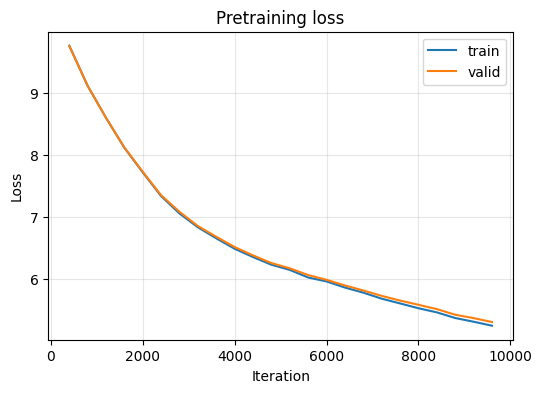

In [19]:
import matplotlib.pyplot as plt
import numpy as np

eval_every = eval_iters  # e.g., 500

# Convert each tensor to float on CPU
train_loss_np = [float(t.cpu()) for t in train_loss_list]
valid_loss_np = [float(t.cpu()) for t in validation_loss_list]

steps = np.arange(1, len(train_loss_np) + 1) * eval_every

plt.figure(figsize=(6,4))
plt.plot(steps, train_loss_np, label='train')
plt.plot(steps, valid_loss_np, label='valid')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Pretraining loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



In [20]:
import torch

ckpt_path = "best_model_params.pt"  # you saved this in the loop
model.load_state_dict(torch.load(ckpt_path, map_location=device))
model.eval()

GPT(
  (transformer): ModuleDict(
    (wte): Embedding(42380, 384)
    (wpe): Embedding(128, 384)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-5): 6 x Block(
        (ln1): LayerNorm()
        (attn): CausalSelfAttention(
          (c_attn): Linear(in_features=384, out_features=1152, bias=True)
          (c_proj): Linear(in_features=384, out_features=384, bias=True)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln2): LayerNorm()
        (mlp): MLP(
          (c_fc): Linear(in_features=384, out_features=1536, bias=True)
          (gelu): GELU(approximate='none')
          (c_proj): Linear(in_features=1536, out_features=384, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm()
  )
  (lm_head): Linear(in_features=384, out_features=42380, bias=False)
)

In [ ]:
os.makedirs("/content/hoc", exist_ok=True)

# Download HoC dataset TSV files directly
!wget -q -O /content/hoc/train.tsv https://raw.githubusercontent.com/microsoft/BioGPT/main/data/Hallmarks_of_Cancer/train.tsv
!wget -q -O /content/hoc/valid.tsv https://raw.githubusercontent.com/microsoft/BioGPT/main/data/Hallmarks_of_Cancer/valid.tsv
!wget -q -O /content/hoc/test.tsv  https://raw.githubusercontent.com/microsoft/BioGPT/main/data/Hallmarks_of_Cancer/test.tsv

print("TSV files downloaded to /content/hoc")

In [ ]:
# ===== Zero-shot HoC evaluation for your PRE-TRAINED GPT (with cue + EOS delay) =====
# Uses your existing GPT / GPTConfig and loads ckpt_path="best_model_params.pt"

# installs
!pip -q install sacremoses==0.0.53 scikit-learn==1.5.1

import os, math, difflib, tempfile, subprocess
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import torch
import torch.nn.functional as F
from sklearn.metrics import precision_recall_fscore_support
from sacremoses import MosesDetokenizer

# ---------- paths ----------
HOC_DIR     = "/content/hoc"                 # train.tsv / valid.tsv / test.tsv live here
BPE_CODES   = "/content/bpecodes"            # from BioGPT
DICT_TXT    = "/content/dict.txt"            # from BioGPT
FASTBPE_BIN = "/content/fastBPE/fast"        # compiled earlier
ckpt_path   = ckpt_path if 'ckpt_path' in globals() else "best_model_params.pt"

os.makedirs(HOC_DIR, exist_ok=True)

# ---------- ensure fastBPE + BioGPT codes/dict ----------
if not os.path.exists(FASTBPE_BIN):
    !git clone -q https://github.com/glample/fastBPE.git /content/fastBPE
    %cd /content/fastBPE
    !g++ -std=c++11 -O3 -pthread fastBPE/main.cc -IfastBPE -o fast
    %cd /content
if not os.path.exists(BPE_CODES):
    !wget -q -O /content/bpecodes https://raw.githubusercontent.com/microsoft/BioGPT/main/data/BioGPT/bpecodes
if not os.path.exists(DICT_TXT):
    !wget -q -O /content/dict.txt  https://raw.githubusercontent.com/microsoft/BioGPT/main/data/BioGPT/dict.txt

# ---------- vocab maps ----------
token2id, id2token = {}, {}
with open(DICT_TXT, encoding="utf-8") as f:
    for i, line in enumerate(f):
        tok = line.split()[0]
        token2id[tok] = i
        id2token[i] = tok

eos_id = token2id.get("</s>", 0)
pad_id = eos_id  # safe pad; loss is masked anyway

# ---------- BPE helpers ----------
def bpe_encode_lines(lines, shard_size=2000, desc="BPE"):
    if len(lines) == 0:
        return []
    out = []
    with tempfile.TemporaryDirectory() as td:
        for start in tqdm(range(0, len(lines), shard_size), desc=f"{desc} ({len(lines)} lines)", leave=False):
            chunk = lines[start:start+shard_size]
            src = os.path.join(td, f"src_{start}.txt")
            dst = os.path.join(td, f"dst_{start}.bpe")
            with open(src, "w", encoding="utf-8") as w:
                for s in chunk: w.write((s or "").strip() + "\n")
            subprocess.check_call([FASTBPE_BIN, "applybpe", dst, src, BPE_CODES])
            with open(dst, "r", encoding="utf-8") as r:
                for line in r:
                    out.append(line.strip().split())
    return out

def tokens_to_ids(bpe_tokens):
    ids = []
    for t in bpe_tokens:
        ids.append(token2id.get(t, pad_id))
    return ids, 0

def bpe_decode_tokens(bpe_tokens):
    s = ' '.join(bpe_tokens).replace('@@ ', '')
    return MosesDetokenizer(lang='en').detokenize(s.split())

# ---------- load HoC test ----------
def load_hoc_tsv(path):
    df = pd.read_csv(path, sep="\t", header=None, dtype=str).fillna("")
    assert df.shape[1] == 2, f"{path} must have 2 columns"
    avg0, avg1 = df[0].astype(str).str.len().mean(), df[1].astype(str).str.len().mean()
    df.columns = ["text","label"] if avg0 > avg1 else ["label","text"]
    return df

test_path = os.path.join(HOC_DIR, "test.tsv")
assert os.path.exists(test_path), f"Missing {test_path}"
test_df = load_hoc_tsv(test_path)
print("Test size:", len(test_df))

# ---------- the 10 Hallmarks (no 'empty') ----------
HALLMARKS = [
    "activating invasion and metastasis",
    "avoiding immune destruction",
    "cellular energetics",
    "enabling replicative immortality",
    "evading growth suppressors",
    "genomic instability and mutation",
    "inducing angiogenesis",
    "resisting cell death",
    "sustaining proliferative signaling",
    "tumor promoting inflammation",
]

def split_labels(s: str):
    s = (s or "").strip()
    if not s: return []
    for sep in [",",";","|"]:
        if sep in s:
            return [p.strip() for p in s.split(sep) if p.strip()]
    return [s]

def normalize_labels(labs):
    keep, low = [], [L.lower() for L in HALLMARKS]
    for x in labs:
        xl = x.lower().strip()
        if xl in low:
            keep.append(HALLMARKS[low.index(xl)])
        else:
            best = difflib.get_close_matches(xl, low, n=1, cutoff=0.7)
            if best:
                keep.append(HALLMARKS[low.index(best[0])])
    return sorted(dict.fromkeys(keep))

# ---------- Build allowed-token mask (labels + separators + </s>) & first-step forbids ----------
def build_allowed_mask_and_first_forbid(vocab_size, device):
    allowed = set()
    sep_ids = set()
    # Hallmark tokens (all tokens that appear in these strings)
    for bpe in bpe_encode_lines(HALLMARKS, desc="BPE hallmarks"):
        ids, _ = tokens_to_ids(bpe); allowed.update(ids)
    # Separators; we also record their token ids to block at the first step
    SEPS = [", ", ",", "; ", ";", "|", " and "]
    for sep in SEPS:
        bpe = bpe_encode_lines([sep], desc="BPE seps")[0]
        ids, _ = tokens_to_ids(bpe)
        allowed.update(ids)
        sep_ids.update(ids)
    allowed.add(eos_id)

    mask = torch.full((vocab_size,), float('-inf'), device=device)
    mask[list(allowed)] = 0.0
    first_forbid = torch.zeros((vocab_size,), dtype=torch.bool, device=device)
    first_forbid[list(sep_ids)] = True
    first_forbid[eos_id] = True  # never allow EOS as the first generated token
    return mask, first_forbid

device = "cuda" if torch.cuda.is_available() else "cpu"
ALLOWED_MASK, FIRST_STEP_FORBID = build_allowed_mask_and_first_forbid(len(token2id), device)

# ---------- Build contexts (text </s> + textual cue) ----------
PROMPT_TEXT = " hallmarks of cancer:"  # small cue after abstract
PROMPT_BPE  = bpe_encode_lines([PROMPT_TEXT], desc="BPE prompt")[0]
PROMPT_IDS, _ = tokens_to_ids(PROMPT_BPE)

def make_context_with_prompt(df):
    texts = df["text"].astype(str).tolist()
    bpes  = bpe_encode_lines(texts, desc="BPE test ctx")
    ctx = []
    for bpe in bpes:
        ids, _ = tokens_to_ids(bpe)
        ctx.append(np.array(ids + [eos_id] + PROMPT_IDS, dtype=np.int64))
    return ctx

def pad_batch(seqs):
    L = max(len(s) for s in seqs)
    out = np.full((len(seqs), L), pad_id, dtype=np.int64)
    for i, s in enumerate(seqs):
        out[i, :len(s)] = s
    return torch.from_numpy(out)

def ids_to_tokens(ids):
    return [id2token.get(int(i), "<unk>") for i in ids]

def to_canonical(pred_chunk: str):
    s = (pred_chunk or "").strip().lower()
    low = [L.lower() for L in HALLMARKS]
    if s in low: return HALLMARKS[low.index(s)]
    best = difflib.get_close_matches(s, low, n=1, cutoff=0.7)
    return HALLMARKS[low.index(best[0])] if best else None

# ---------- Require your GPT & GPTConfig from pretraining ----------
assert 'GPT' in globals(), "Please define your GPT class (same as pretraining) before running this cell."
assert 'GPTConfig' in globals(), "Please ensure GPTConfig is defined."

cfg = GPTConfig(
    vocab_size=len(token2id),
    block_size=(config.block_size if 'config' in globals() else 128),
    n_layer=(config.n_layer if 'config' in globals() else 6),
    n_head=(config.n_head if 'config' in globals() else 6),
    n_embd=(config.n_embd if 'config' in globals() else 384),
    dropout=(config.dropout if 'config' in globals() else 0.1),
    bias=(config.bias if 'config' in globals() else True),
)
base = GPT(cfg).to(device)

# safe WPE resize when loading the checkpoint
def load_with_wpe_resize(model, ckpt_path):
    sd = torch.load(ckpt_path, map_location="cpu")
    key = "transformer.wpe.weight"
    if key in sd:
        old = sd[key]
        new_w = model.transformer.wpe.weight
        new_len = new_w.shape[0]
        if old.shape[0] != new_len:
            new = new_w.data.clone()
            n = min(new_len, old.shape[0])
            new[:n] = old[:n]
            if new_len > n:
                torch.nn.init.normal_(new[n:], mean=0.0, std=0.02)
            sd[key] = new
    missing, unexpected = base.load_state_dict(sd, strict=False)
    if missing or unexpected:
        print("Missing keys:", missing)
    print("Loaded PRETRAINED checkpoint:", ckpt_path)

assert os.path.exists(ckpt_path), f"Checkpoint not found: {ckpt_path}"
load_with_wpe_resize(base, ckpt_path)
base.eval()

# ---------- Constrained greedy decode with cue + EOS delay ----------
@torch.no_grad()
def gpt_generate_with_cue(model, idx, allowed_mask, first_step_forbid,
                          max_new_tokens=24, min_new_before_eos=2, eos_penalty=-2.0, temperature=0.0):
    """
    - Restrict vocabulary with `allowed_mask`
    - For the very first generated token, forbid separators + EOS
    - For the first `min_new_before_eos` tokens, disallow EOS entirely
    - After that, add a small penalty to EOS (so it doesn't end too early)
    """
    out = idx.clone()
    B = out.size(0)
    finished = torch.zeros(B, dtype=torch.bool, device=out.device)
    steps = 0
    for _ in range(max_new_tokens):
        ctx = out[:, -model.config.block_size:]
        logits, _ = model(ctx)                 # (B,1,V)
        logits = logits[:, -1, :]              # (B,V)

        # restrict to label vocab
        logits = logits + allowed_mask

        # first token: block separators + EOS
        if steps == 0:
            logits[:, first_step_forbid] = -1e9

        # delay EOS for a couple steps, then mildly penalize
        if steps < min_new_before_eos:
            logits[:, eos_id] = -1e9
        else:
            logits[:, eos_id] += eos_penalty

        # pick next
        if temperature <= 0:
            next_id = torch.argmax(logits, dim=-1)
        else:
            probs = F.softmax(logits / temperature, dim=-1)
            next_id = torch.multinomial(probs, num_samples=1).squeeze(1)

        next_id = next_id.masked_fill(finished, eos_id)
        out = torch.cat([out, next_id.unsqueeze(1)], dim=1)
        finished |= (next_id == eos_id)
        steps += 1
        if bool(finished.all()):
            break
    return out[:, idx.size(1):]

@torch.no_grad()
def predict_labels_for_batch_generative(xb):
    gens = gpt_generate_with_cue(
        base, xb, allowed_mask=ALLOWED_MASK, first_step_forbid=FIRST_STEP_FORBID,
        max_new_tokens=24, min_new_before_eos=2, eos_penalty=-2.0, temperature=0.0
    )
    preds = []
    for g in gens:
        toks = ids_to_tokens(g.detach().cpu().numpy())
        toks = toks[: toks.index("</s>")] if "</s>" in toks else toks
        label_str = bpe_decode_tokens(toks).strip().lower()

        parts = []
        for sep in [",",";","|"]:
            if sep in label_str:
                parts = [p.strip() for p in label_str.split(sep) if p.strip()]
                break
        if not parts:
            parts = [label_str] if label_str else []

        mapped = []
        for p in parts:
            can = to_canonical(p)
            if can and can not in mapped:
                mapped.append(can)
        preds.append(mapped)  # may be []
    return preds

# ---------- Run decoding on TEST ----------
ctx_test = make_context_with_prompt(test_df)
preds_all = []
B = 32
for i in tqdm(range(0, len(ctx_test), B), desc="Decoding (pretrain+cue, test)"):
    xb = pad_batch(ctx_test[i:i+B]).to(device)
    preds_all.extend(predict_labels_for_batch_generative(xb))

# ---------- Ground truth & metrics (10 hallmarks only) ----------
y_true = [ normalize_labels(split_labels(s)) for s in test_df["label"].astype(str).tolist() ]
LABELS = HALLMARKS
LIDX = {l:i for i,l in enumerate(LABELS)}
def binarize(labs):
    v = [0]*len(LABELS)
    for l in labs:
        if l in LIDX: v[LIDX[l]] = 1
    return v

Y_true = np.array([binarize(l) for l in y_true], dtype=np.int64)
Y_pred = np.array([binarize(l) for l in preds_all], dtype=np.int64)

micro_p, micro_r, micro_f1, _ = precision_recall_fscore_support(Y_true, Y_pred, average='micro', zero_division=0)
macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(Y_true, Y_pred, average='macro', zero_division=0)

print(f"\n[PRETRAIN+cue] HALLMARKS-ONLY  Micro  P/R/F1: {micro_p:.4f} / {micro_r:.4f} / {micro_f1:.4f}")
print(  f"[PRETRAIN+cue] HALLMARKS-ONLY  Macro  P/R/F1: {macro_p:.4f} / {macro_r:.4f} / {macro_f1:.4f}")

perclass = precision_recall_fscore_support(Y_true, Y_pred, average=None, zero_division=0)
per_df_pre = pd.DataFrame({
    "label": LABELS,
    "precision": perclass[0],
    "recall":    perclass[1],
    "f1":        perclass[2],
    "support":   perclass[3],
}).sort_values("label")

print("\nPer-class results (PRETRAIN+cue, 10 hallmarks):")
print(per_df_pre.to_string(index=False))

per_df_pre.to_csv("hoc_test_results_pretrain_cue.csv", index=False)
print("Saved: hoc_test_results_pretrain_cue.csv")

# (optional) exclude empty-label rows from eval:
# mask = (Y_true.sum(axis=1) > 0)
# ... recompute scores on Y_true[mask], Y_pred[mask]


In [ ]:
# === Show 10 "questions" (abstract + prompt) and the model's answers (pretrained+cue) ===
import os, difflib, numpy as np, pandas as pd, torch, torch.nn.functional as F
from tqdm.auto import tqdm
from sklearn.metrics import precision_recall_fscore_support

# ---- Assumptions / fallbacks ----
HOC_DIR   = globals().get("HOC_DIR", "/content/hoc")
ckpt_path = globals().get("ckpt_path", "best_model_params.pt")
device    = "cuda" if torch.cuda.is_available() else "cpu"

# Hallmarks (10 classes, no "empty")
HALLMARKS = [
    "activating invasion and metastasis",
    "avoiding immune destruction",
    "cellular energetics",
    "enabling replicative immortality",
    "evading growth suppressors",
    "genomic instability and mutation",
    "inducing angiogenesis",
    "resisting cell death",
    "sustaining proliferative signaling",
    "tumor promoting inflammation",
]

# ---------- Helper fallbacks if not defined earlier ----------
def _need(name): return name not in globals()

# TSV loader
if _need("load_hoc_tsv"):
    def load_hoc_tsv(path):
        df = pd.read_csv(path, sep="\t", header=None, dtype=str).fillna("")
        assert df.shape[1] == 2, f"{path} must have 2 columns"
        avg0, avg1 = df[0].astype(str).str.len().mean(), df[1].astype(str).str.len().mean()
        df.columns = ["text","label"] if avg0 > avg1 else ["label","text"]
        return df

# If test_df not in memory, load it
if "test_df" not in globals():
    test_df = load_hoc_tsv(os.path.join(HOC_DIR, "test.tsv"))

# Simple label split/normalization utilities
def split_labels(s: str):
    s = (s or "").strip()
    if not s: return []
    for sep in [",",";","|"]:
        if sep in s:
            return [p.strip() for p in s.split(sep) if p.strip()]
    return [s]

def normalize_labels(labs):
    keep, low = [], [L.lower() for L in HALLMARKS]
    for x in labs:
        xl = x.lower().strip()
        if xl in low:
            keep.append(HALLMARKS[low.index(xl)])
        else:
            best = difflib.get_close_matches(xl, low, n=1, cutoff=0.7)
            if best:
                keep.append(HALLMARKS[low.index(best[0])])
    # de-dup & stable order
    seen, out = set(), []
    for k in keep:
        if k not in seen:
            seen.add(k); out.append(k)
    return out

# BPE helpers (must exist: token2id, id2token, bpe_encode_lines, tokens_to_ids, bpe_decode_tokens, eos_id, pad_id)
for req in ["token2id","id2token","bpe_encode_lines","tokens_to_ids","bpe_decode_tokens","eos_id","pad_id"]:
    assert req in globals(), f"Missing `{req}` — run the setup cell that defines dict/bpecodes and BPE helpers."

# Build allowed-token mask & first-step forbids if not present
if _need("ALLOWED_MASK") or _need("FIRST_STEP_FORBID"):
    def build_allowed_mask_and_first_forbid(vocab_size, device):
        allowed = set(); sep_ids = set()
        # all tokens that appear in hallmark strings
        for bpe in bpe_encode_lines(HALLMARKS, desc="BPE hallmarks"):
            ids, _ = tokens_to_ids(bpe); allowed.update(ids)
        # separators (also block them on very first generated step)
        SEPS = [", ", ",", "; ", ";", "|", " and "]
        for sep in SEPS:
            bpe = bpe_encode_lines([sep], desc="BPE seps")[0]
            ids, _ = tokens_to_ids(bpe); allowed.update(ids); sep_ids.update(ids)
        allowed.add(eos_id)
        mask = torch.full((vocab_size,), float('-inf'), device=device)
        mask[list(allowed)] = 0.0
        first_forbid = torch.zeros((vocab_size,), dtype=torch.bool, device=device)
        first_forbid[list(sep_ids)] = True
        first_forbid[eos_id] = True
        return mask, first_forbid
    ALLOWED_MASK, FIRST_STEP_FORBID = build_allowed_mask_and_first_forbid(len(token2id), device)

# Prompt (the "question" cue)
PROMPT_TEXT = " hallmarks of cancer:"
PROMPT_BPE  = bpe_encode_lines([PROMPT_TEXT], desc="BPE prompt")[0]
PROMPT_IDS, _ = tokens_to_ids(PROMPT_BPE)

# Build contexts with prompt
def make_context_with_prompt(rows):
    bpes = bpe_encode_lines(rows["text"].astype(str).tolist(), desc="BPE ctx (sample)")
    ctx = []
    for bpe in bpes:
        ids, _ = tokens_to_ids(bpe)
        ctx.append(np.array(ids + [eos_id] + PROMPT_IDS, dtype=np.int64))
    return ctx

def pad_batch(seqs):
    L = max(len(s) for s in seqs)
    out = np.full((len(seqs), L), pad_id, dtype=np.int64)
    for i, s in enumerate(seqs):
        out[i, :len(s)] = s
    return torch.from_numpy(out)

def ids_to_tokens(ids):
    return [id2token.get(int(i), "<unk>") for i in ids]

def to_canonical(pred_chunk: str):
    s = (pred_chunk or "").strip().lower()
    low = [L.lower() for L in HALLMARKS]
    if s in low: return HALLMARKS[low.index(s)]
    best = difflib.get_close_matches(s, low, n=1, cutoff=0.7)
    return HALLMARKS[low.index(best[0])] if best else None

# If the pretrained model (`base`) isn’t loaded yet, load it
if _need("base"):
    assert 'GPT' in globals() and 'GPTConfig' in globals(), "Define GPT and GPTConfig first (your pretraining classes)."
    assert os.path.exists(ckpt_path), f"Checkpoint not found: {ckpt_path}"
    cfg = GPTConfig(
        vocab_size=len(token2id),
        block_size=(config.block_size if 'config' in globals() else 128),
        n_layer=(config.n_layer if 'config' in globals() else 6),
        n_head=(config.n_head if 'config' in globals() else 6),
        n_embd=(config.n_embd if 'config' in globals() else 384),
        dropout=(config.dropout if 'config' in globals() else 0.1),
        bias=(config.bias if 'config' in globals() else True),
    )
    base = GPT(cfg).to(device)
    # safe WPE resize
    def load_with_wpe_resize(model, path):
        sd = torch.load(path, map_location="cpu")
        key = "transformer.wpe.weight"
        if key in sd:
            old = sd[key]
            new_w = model.transformer.wpe.weight
            new_len = new_w.shape[0]
            if old.shape[0] != new_len:
                new = new_w.data.clone()
                n = min(new_len, old.shape[0])
                new[:n] = old[:n]
                if new_len > n:
                    torch.nn.init.normal_(new[n:], mean=0.0, std=0.02)
                sd[key] = new
        model.load_state_dict(sd, strict=False)
    load_with_wpe_resize(base, ckpt_path)
    base.eval()

# Constrained generation with cue + EOS delay (define if missing)
if _need("gpt_generate_with_cue"):
    @torch.no_grad()
    def gpt_generate_with_cue(model, idx, allowed_mask, first_step_forbid,
                              max_new_tokens=24, min_new_before_eos=2, eos_penalty=-2.0, temperature=0.0):
        out = idx.clone()
        B = out.size(0)
        finished = torch.zeros(B, dtype=torch.bool, device=out.device)
        steps = 0
        for _ in range(max_new_tokens):
            ctx = out[:, -model.config.block_size:]
            logits, _ = model(ctx)           # (B,1,V)
            logits = logits[:, -1, :]        # (B,V)
            logits = logits + allowed_mask    # restrict vocab
            if steps == 0:
                logits[:, first_step_forbid] = -1e9
            if steps < min_new_before_eos:
                logits[:, eos_id] = -1e9
            else:
                logits[:, eos_id] += eos_penalty
            if temperature <= 0:
                next_id = torch.argmax(logits, dim=-1)
            else:
                probs = F.softmax(logits / temperature, dim=-1)
                next_id = torch.multinomial(probs, num_samples=1).squeeze(1)
            next_id = next_id.masked_fill(finished, eos_id)
            out = torch.cat([out, next_id.unsqueeze(1)], dim=1)
            finished |= (next_id == eos_id)
            steps += 1
            if bool(finished.all()):
                break
        return out[:, idx.size(1):]

# ---------- Sample 10 and print Q&A ----------
SAMPLE_N = 10
sample = test_df.sample(n=min(SAMPLE_N, len(test_df)), random_state=42).reset_index(drop=True)

# prepare contexts
ctx = make_context_with_prompt(sample)
B = 10  # single batch is fine here
xb = pad_batch(ctx).to(device)

# generate
gens = gpt_generate_with_cue(
    base, xb, allowed_mask=ALLOWED_MASK, first_step_forbid=FIRST_STEP_FORBID,
    max_new_tokens=24, min_new_before_eos=2, eos_penalty=-2.0, temperature=0.0
)

# decode + print
for i, g in enumerate(gens):
    text = sample.loc[i, "text"]
    gold = normalize_labels(split_labels(sample.loc[i, "label"]))

    toks = ids_to_tokens(g.detach().cpu().numpy())
    toks = toks[: toks.index("</s>")] if "</s>" in toks else toks
    raw = ' '.join(toks).replace('@@ ', '').strip().lower()

    # split raw into parts and map to canonical labels
    parts = []
    for sep in [",",";","|"]:
        if sep in raw:
            parts = [p.strip() for p in raw.split(sep) if p.strip()]
            break
    if not parts:
        parts = [raw] if raw else []
    pred = []
    for p in parts:
        can = to_canonical(p)
        if can and can not in pred:
            pred.append(can)

    print(f"\n=== Example {i+1} ===")
    print("QUESTION:")
    print("Abstract:", (text.replace("\n"," ")[:350] + ("..." if len(text) > 350 else "")))
    print("Prompt:  hallmarks of cancer:")
    print("GOLD:   ", gold if gold else "[]")
    print("ANSWER: ", pred if pred else "[]")
    print("Raw gen:", raw if raw else "<empty>")
